# Homework 1: Problem 5
Rheobase and the shape of the f–I curve in Hodgkin-Huxley. The provided hh_sim code integrates
the classical Hodgkin-Huxley model under constant current Id and returns the spike times. If you are not
working in MATLAB, port it first; the gating rate functions and parameter values are all in the file, including two removable singularities that need care. The rheobase is the smallest constant current that produces
sustained repetitive firing.

In [ ]:
# Setup - hh_sim.py from canvas files
import numpy as np
from scipy.integrate import solve_ivp

__all__ = ["hh_sim"]


# ---- gating rate functions (ms^-1), with removable singularities patched ----
def _am(V):
    return 1.0 if abs(V - 25) < 1e-6 else 0.1 * (25 - V) / (np.exp((25 - V) / 10) - 1)


def _bm(V):
    return 4 * np.exp(-V / 18)


def _ah(V):
    return 0.07 * np.exp(-V / 20)


def _bh(V):
    return 1 / (np.exp((30 - V) / 10) + 1)


def _an(V):
    return 0.1 if abs(V - 10) < 1e-6 else 0.01 * (10 - V) / (np.exp((10 - V) / 10) - 1)


def _bn(V):
    return 0.125 * np.exp(-V / 80)


def hh_sim(Id=7.0, tmax=300.0, gK=36.0, gNa=120.0, skipfrac=0.4):
    """Integrate the HH model under constant current.

    Parameters
    ----------
    Id : injected current density (uA/cm^2). Defaults to 7, above
         rheobase, so hh_sim() with no arguments gives repetitive
         firing.
    tmax : simulation duration (ms).
    gK, gNa : maximal conductances (mS/cm^2).
    skipfrac : fraction of the trace discarded before counting spikes, so
        that the onset transient is not mistaken for repetitive firing.

    Returns
    -------
    t, V : time vector (ms) and voltage trace (mV).
    spk : spike times, upward crossings of 40 mV.
    rate : mean firing rate in Hz over the counted window, 0 if fewer
        than two spikes.
    """
    C, gL, ENa, EK, EL = 1.0, 0.3, 115.0, -12.0, 10.6

    def rhs(_, y):
        V, m, h, n = y
        INa = gNa * m**3 * h * (V - ENa)
        IK = gK * n**4 * (V - EK)
        IL = gL * (V - EL)
        return [
            (Id - INa - IK - IL) / C,
            _am(V) * (1 - m) - _bm(V) * m,
            _ah(V) * (1 - h) - _bh(V) * h,
            _an(V) * (1 - n) - _bn(V) * n,
        ]

    V0 = 0.0  # steady state gating at rest
    y0 = [
        V0,
        _am(V0) / (_am(V0) + _bm(V0)),
        _ah(V0) / (_ah(V0) + _bh(V0)),
        _an(V0) / (_an(V0) + _bn(V0)),
    ]

    t = np.arange(0, tmax + 1e-9, 0.01)
    sol = solve_ivp(rhs, [0, tmax], y0, method="BDF", t_eval=t,
                    rtol=1e-8, atol=1e-10, max_step=0.05)
    V = sol.y[0]

    i0 = max(1, int(round(skipfrac * len(t))))
    up = np.flatnonzero((V[i0:-1] < 40) & (V[i0 + 1:] >= 40)) + i0
    spk = t[up]

    rate = 1000 * (len(spk) - 1) / (spk[-1] - spk[0]) if len(spk) >= 2 else 0.0
    return t, V, spk, rate


if __name__ == "__main__":
    t, V, spk, rate = hh_sim()
    print(f"Id = 7: {len(spk)} spikes, rate = {rate:.1f} Hz")

Id = 7: 11 spikes, rate = 58.3 Hz


In [ ]:
# Check on def _am and def _an to ensure not "nan" to prevent "undefined" coming up in the math
print(_am(25))
print(_an(10))

1.0
0.1


In [ ]:
# More setup
import matplotlib.pyplot as plt
import pandas as pd

# Check action potential firing 
def firing(Id, gK, tmax = 300, skipfrac = 0.4, minspk = 5):
    _, _, spk, _, = hh_sim(Id, tmax, gK, skipfrac=skipfrac)
    return len(spk) >= minspk

# Rheobase bisection
def rheobase_bisection(lo, hi, gK, tol = 1e-4):
    assert not firing(lo, gK) and firing(hi, gK)  # create bounds for rheobase bisection
    while (hi - lo) > tol:
        mid = 0.5 * (lo + hi)
        if firing(mid, gK):
            hi = mid
        else:
            lo = mid
    return hi

# Check the firing rate when nearest to rheobase
def onset(I_rheobase, gK, tmax = 300, skipfrac = 0.4, epsilon = 0.001):
    _, _, spk, rate = hh_sim(I_rheobase + epsilon, tmax = tmax, gK = gK, skipfrac = skipfrac)
    return rate

# f-i curve curve setup
def F_I_curve(I_rheobase, gK, span = 5, stepsize_s = 0.1, stepsize_l = 0.5, tmax = 300, skipfrac = 0.4 ):
    currents = np.concatenate([
        np.arange(I_rheobase, I_rheobase + 1.0, stepsize_s),    # check with small stepsize
        np.arange(I_rheobase + 1.0, I_rheobase + span, stepsize_l)     # check with larger stepsize
    ])
    rates = np.array([
        hh_sim(Id = I, tmax = tmax, gK = gK, skipfrac = skipfrac)[3] for I in currents
    ])
    return currents, rates


## Part a:
Locate the rheobase to three digits by bisection rather than by hand. Report the value, state your criterion
for ‘repetitive’, and plot the voltage traces just below and just above it on axes with identical limits.

In [36]:
# Rough search for where firing turns on and off for gK = 36
for Id in np.arange(5, 7, 0.1):
    print(f"Id = {Id:.3f}", firing(Id, gK = 36.0))

Id = 5.000 False
Id = 5.100 False
Id = 5.200 False
Id = 5.300 False
Id = 5.400 False
Id = 5.500 False
Id = 5.600 False
Id = 5.700 False
Id = 5.800 False
Id = 5.900 False
Id = 6.000 False
Id = 6.100 False
Id = 6.200 False
Id = 6.300 True
Id = 6.400 True
Id = 6.500 True
Id = 6.600 True
Id = 6.700 True
Id = 6.800 True
Id = 6.900 True


In [37]:
I_rheobase_36 = round(rheobase_bisection(lo = 6.2, hi =6.3 , gK = 36.0), 3)  # find rheobase bisection, round to 4 decimal places. Above cell tells us that there is no firing at 6.2 but there is at 6.3, giving the rheobase bounds
print("Rheobase (gK = 36.0) = ", I_rheobase_36)

Rheobase (gK = 36.0) =  6.26


The rheobase was calculated to be 6.258 mV. I set the minimum firing rate to 5 spikes, so if the number of spikes that occur is greater than 5, it is to be considered "repetitive spiking".  

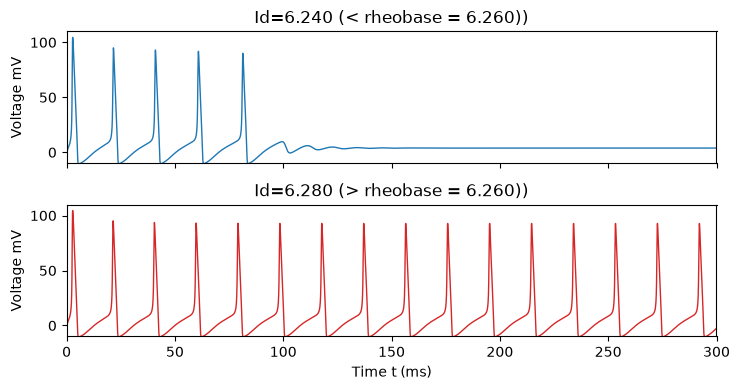

In [39]:
Id_under = I_rheobase_36 - 0.02     # below rheobase
Id_over = I_rheobase_36 + 0.02      # above rheobase

t1, V1, spk1, r1 = hh_sim(Id = Id_under, tmax = 300, gK = 36.0)
t2, V2, spk2, r2 = hh_sim(Id = Id_over, tmax = 300, gK = 36.0)

fig, axes = plt.subplots(2, 1, sharex = True, sharey = True, figsize = (7.5, 4))
axes[0].plot(t1, V1, lw = 1.0, color="tab:blue")
axes[0].set_title(f"Id={Id_under:.3f} (< rheobase = {I_rheobase_36:.3f}))") 
axes[1].plot(t2, V2, lw = 1.0, color = "tab:red")
axes[1].set_title(f"Id={Id_over:.3f} (> rheobase = {I_rheobase_36:.3f}))")
axes[1].set_xlabel("Time t (ms)")

for i in axes:
    i.set_ylabel("Voltage mV")
    i.set_xlim(0,300)
    i.set_ylim(-10, 110)

plt.tight_layout()
plt.show()


## Part b:
Compute the firing rate at a sequence of currents from just above rheobase up to roughly twice it, plot the f–I curve, and report the onset rate to three digits. Does the rate rise continuously from zero, or switch on at a nonzero value? Which of the two bifurcation scenarios from problems 2 and 3 does Hodgkin-Huxley resemble, and what is the physiological consequence?

In [41]:
firing_rate_36 = onset(I_rheobase_36, gK = 36.0)
print(f"The onset rate at gK = 36 is: {firing_rate_36:.3f} Hz")

The onset rate at gK = 36 is: 49.136 Hz


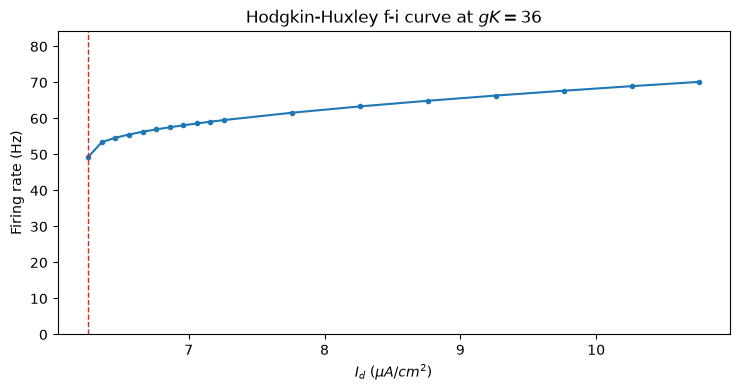

In [45]:
# Plot curves
I36, rate36 = F_I_curve(I_rheobase_36, gK = 36.0)

plt.figure(figsize = (7.5, 4))
plt.plot(I36, rate36, "o-", ms = 3, color = "tab:blue")
plt.axvline(I_rheobase_36, color = "tab:red", ls = "--", lw = 1)
plt.xlabel(r"$I_d$ ($\mu A/cm^2$)")
plt.ylabel(r"Firing rate (Hz)")
plt.title(r"Hodgkin-Huxley f-i curve at $gK = 36$")
plt.ylim(0, max(rate36)*1.2)
plt.tight_layout()
plt.show()


The onset rate at gK = 36 is 49.136 Hz, with the frequency rate switching on at about at a nonzero value. This Hodgkin-Huxley curve resembles the SNIC bifurcation seen in problem 3 of this assigment, which is physiologically consequential as it demonstrates how a resting neurons transitions to a state of repeatedly firing and represents class I neuron excitability where neurons can fire at low frequencies.

## Part c:
Change gK from 36 to 30 (mS/cm2) and recompute the rheobase by the same bisection. Report both rheobase values to three digits in a small table, and overlay the two f–I curves on a single set of axes with the two rheobase values marked. Did the rheobase go up or down? Explain the result in terms of the currents in the model, and say whether the shape of the curve changed or only its position.

In [47]:
# Rough search for where firing turns on and off for gK = 30
for Id in np.arange(2, 3, 0.1):
    print(f"Id = {Id:.3f}", firing(Id, gK = 30.0))

Id = 2.000 False
Id = 2.100 False
Id = 2.200 False
Id = 2.300 False
Id = 2.400 False
Id = 2.500 False
Id = 2.600 False
Id = 2.700 False
Id = 2.800 True
Id = 2.900 True


In [55]:
I_rheobase_30 = round(rheobase_bisection(lo = 2.7, hi = 2.8, gK = 30.0), 3)
rate30 = onset(I_rheobase_30, gK = 30.0)
I30, rate_gK30 = F_I_curve(I_rheobase_30, gK = 30.0)

df = pd.DataFrame({
    "gK (mS/cm^2)" : [30, 36], 
    "Rheobase (uA/cm^2)" : [I_rheobase_30, I_rheobase_36], 
    "Frequency onset rate (Hz)" : [round(rate30, 3), round(firing_rate_36, 3)]
})

df

,gK (mS/cm^2),Rheobase (uA/cm^2),Frequency onset rate (Hz)
0,30,2.775,44.033
1,36,6.260,49.136


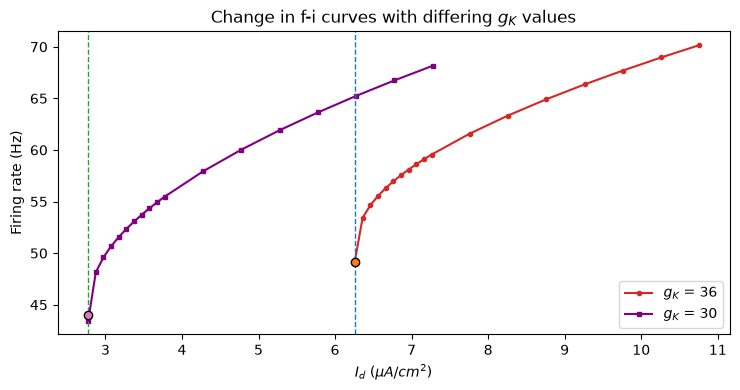

In [58]:
# Plots
plt.figure(figsize = (7.5, 4))
plt.plot(I36, rate36, "o-", ms = 3, color = "tab:red", label = "$g_K$ = 36" )
plt.plot(I30, rate_gK30, "s-", ms = 3, color = "purple", label = "$g_K$ = 30")
plt.axvline(I_rheobase_36, color = "tab:blue", ls = "--", lw = 1)
plt.axvline(I_rheobase_30, color = "tab:green", ls = "--", lw = 1)
plt.scatter([I_rheobase_36], [firing_rate_36], color = "tab:orange", zorder = 5, edgecolor = "k")
plt.scatter([I_rheobase_30], [rate30], color = "tab:pink", zorder = 5, edgecolor = "k")
plt.xlabel(r"$I_d$ ($\mu A/cm^2$)")
plt.ylabel(r"Firing rate (Hz)")
plt.title(r"Change in f-i curves with differing $g_K$ values")
plt.legend()
plt.tight_layout()
plt.show()

After changing gK from 36 to 30, the corresponding rheobase values were 2.260 for gK = 36 and 2.775 for gK = 30, showing that the rehobase went down when the value of gK was lowered. The gK value has impact on the frequency of neuron firing rates, as seen in the above plot. The differences in rheobase currents, as seen in the plot, demonstrate a difference in what types of firing rates are able to be achieved, with the lower rheobase at 2.775 having a starting firing frequency of 44.033 Hz, which is about 5 Hz less than what the higher rheobase is able to start firing at. The position of the two curves are different with respect to the x and y axes of this plot. The general shape of the f-i curves presented did not change with the decrease in gK, however the curve representing gK = 30 has a slighly steeper slope than that of the curve for gK = 36.